# Notebook 0: PyMC for NumPyro Users

**Time:** 20--30 minutes

**Purpose:** A compact Rosetta stone for translating NumPyro patterns into PyMC 5. After this notebook you should be able to specify, sample, and post-process a PyMC model without constantly checking the docs.

**Format:** NumPyro code is shown in markdown blocks for reference (not executed). All runnable cells use PyMC.

**Prerequisites:** Basic familiarity with NumPyro (`numpyro.sample`, `dist.*`, `MCMC`, `NUTS`).

## 1. Imports

PyMC uses **PyTensor** (a fork of Theano) as its tensor/autodiff backend, in contrast to NumPyro's JAX. You don't need to interact with PyTensor directly for model building -- PyMC wraps it.

You may see a warning about `g++` not being detected; sampling will still work (Python fallback), just a bit slower for large models.

In [44]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.28.0
ArviZ version: 0.23.4


## 2. Model specification: the key difference

In NumPyro, a model is a **plain Python function**. Random variables are registered via `numpyro.sample(...)` calls inside that function.

In PyMC, a model is built inside a **context manager** (`with pm.Model() as model:`). Each distribution constructor (e.g. `pm.Normal(...)`) registers a variable on the model graph automatically.

| Concept | NumPyro | PyMC 5 |
|---|---|---|
| Model container | Python function | `with pm.Model() as model:` |
| Random variable | `numpyro.sample("x", dist.Normal(0, 1))` | `x = pm.Normal("x", mu=0, sigma=1)` |
| Observed data | `numpyro.sample("y", dist.Normal(mu, s), obs=y)` | `pm.Normal("y", mu=mu, sigma=s, observed=y)` |
| Deterministic | `numpyro.deterministic("d", expr)` | `pm.Deterministic("d", expr)` |
| Plates / vectorisation | `numpyro.plate("i", N)` | `shape=N` or `dims="i"` |

## 3. Worked example: Beta-Bernoulli

### NumPyro version (reference only)

```python
import numpyro
import numpyro.distributions as dist

def beta_binom_model(obs: np.ndarray | None = None) -> None:
    theta = numpyro.sample("theta", dist.Beta(2.0, 5.0))
    numpyro.sample("y", dist.Bernoulli(probs=theta), obs=obs)

# Sampling:
from numpyro.infer import MCMC, NUTS
import jax

kernel = NUTS(beta_binom_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=1000, num_chains=2)
mcmc.run(jax.random.PRNGKey(0), obs=y_obs)
samples = mcmc.get_samples()  # dict of JAX arrays
```

### PyMC version

In [45]:
# Synthetic data
y_obs: np.ndarray = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1])

with pm.Model() as beta_binom:
    theta = pm.Beta("theta", alpha=2.0, beta=5.0)
    y = pm.Bernoulli("y", p=theta, observed=y_obs)

# Inspect the model graph
print("Free (unobserved) RVs:", beta_binom.free_RVs)
print("Observed RVs:         ", beta_binom.observed_RVs)

Free (unobserved) RVs: [theta]
Observed RVs:          [y]


**Key points:**
- The string name `"theta"` is just a label for the trace; by convention it matches the Python variable name.
- `observed=` is PyMC's equivalent of `obs=` in NumPyro.
- The model object holds the computational graph. You can query `free_RVs` (parameters to sample) and `observed_RVs` (data-clamped nodes).

## 4. Sampling

In NumPyro you create a `NUTS` kernel, wrap it in `MCMC`, and call `.run()`. In PyMC you just call `pm.sample()` inside the model context. NUTS is the default sampler.

`pm.sample()` returns an **ArviZ `InferenceData`** object (an xarray-based container). This replaces the dict-of-arrays you get from NumPyro's `mcmc.get_samples()`.

In [46]:
with beta_binom:
    idata = pm.sample(draws=1000, tune=500, chains=2, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [theta]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## 5. Working with InferenceData

The `InferenceData` object has named **groups** (e.g. `posterior`, `posterior_predictive`, `sample_stats`). Each group is an `xarray.Dataset` with dimensions `(chain, draw)`.

This is the biggest ergonomic shift from NumPyro, where you typically work with plain arrays/dicts. The xarray structure is more verbose but plays nicely with ArviZ plotting and summary functions.

In [47]:
# What is idata?
print(type(idata))
print(idata)  # shows available groups

<class 'arviz.data.inference_data.InferenceData'>
Inference data with groups:
	> posterior
	> sample_stats
	> observed_data


In [48]:
# Access posterior draws -- xarray DataArray with dims (chain, draw)
theta_draws = idata.posterior["theta"]
print(f"Shape: {theta_draws.shape}")  # (n_chains, n_draws)
print(f"Posterior mean: {theta_draws.mean().item():.3f}")

# To get a plain numpy array (like NumPyro's mcmc.get_samples()):
theta_np: np.ndarray = theta_draws.values  # shape (chains, draws)
theta_flat: np.ndarray = theta_draws.values.flatten()  # shape (chains * draws,)

Shape: (2, 1000)
Posterior mean: 0.471


In [49]:
# ArviZ summary -- the equivalent of mcmc.print_summary() in NumPyro
az.summary(idata, var_names=["theta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.471,0.117,0.245,0.679,0.004,0.002,812.0,1154.0,1.0


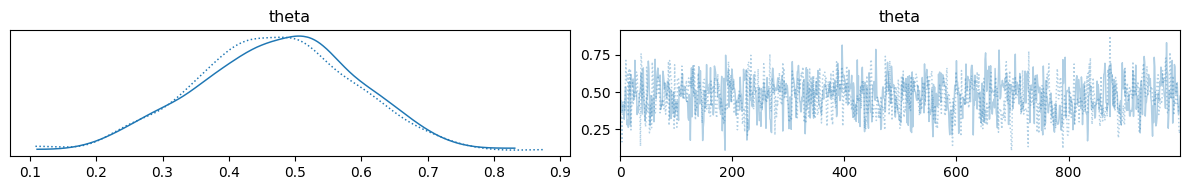

In [50]:
# Trace plot
az.plot_trace(idata, var_names=["theta"])
plt.tight_layout()
plt.show()

## 6. Worked example: Normal linear regression

This example introduces two more PyMC patterns:
- **`pm.Deterministic`**: wraps a derived quantity so it appears in the trace. Equivalent to `numpyro.deterministic(...)`.
- **`pm.HalfNormal`**: a half-normal prior (common for scale parameters). NumPyro equivalent: `dist.HalfNormal(...)`.

### NumPyro version (reference only)

```python
def linreg_model(x: np.ndarray, y: np.ndarray | None = None) -> None:
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0))
    beta = numpyro.sample("beta", dist.Normal(0.0, 10.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = numpyro.deterministic("mu", alpha + beta * x)
    numpyro.sample("y_obs", dist.Normal(mu, sigma), obs=y)
```

In [51]:
# Generate synthetic data
rng = np.random.default_rng(0)
N: int = 50
x: np.ndarray = rng.normal(size=N)
y_reg: np.ndarray = 2.5 * x - 1.0 + rng.normal(scale=0.5, size=N)

# PyMC model
with pm.Model() as linreg:
    alpha = pm.Normal("alpha", mu=0.0, sigma=10.0)
    beta = pm.Normal("beta", mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    mu = pm.Deterministic("mu", alpha + beta * x)
    y_obs_reg = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_reg)

In [52]:
with linreg:
    idata_reg = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [53]:
# Summary for the scalar parameters (not mu, which has shape N)
az.summary(idata_reg, var_names=["alpha", "beta", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.977,0.075,-1.119,-0.837,0.002,0.002,2195.0,1454.0,1.0
beta,2.441,0.081,2.286,2.593,0.002,0.002,2354.0,1582.0,1.0
sigma,0.524,0.054,0.428,0.623,0.001,0.001,2640.0,1319.0,1.0


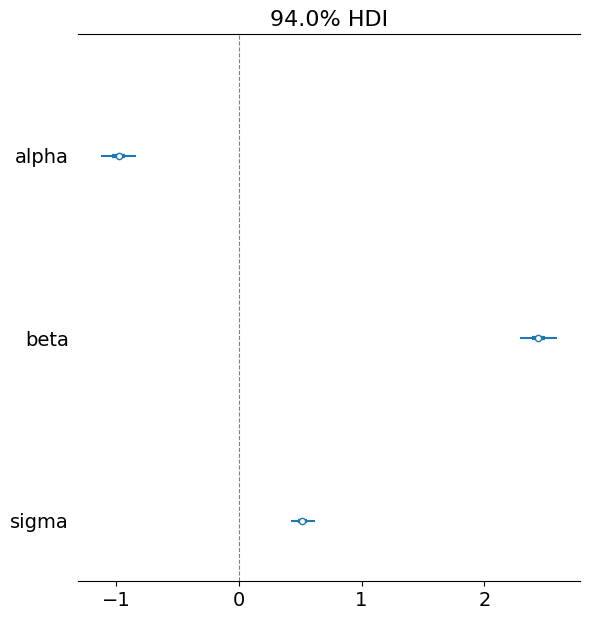

In [54]:
# Forest plot -- quick visual check that posteriors are concentrated
# around the true values (alpha=-1.0, beta=2.5, sigma=0.5)
az.plot_forest(idata_reg, var_names=["alpha", "beta", "sigma"], combined=True)
plt.axvline(0, color="grey", ls="--", lw=0.8)
plt.tight_layout()
plt.show()

## 7. `pm.Data` and posterior predictive

In NumPyro, you generate posterior predictions by passing new data directly to `Predictive(model, posterior_samples)(rng_key, x_new=...)`.

In PyMC, the pattern is more ceremonial:
1. Register **both** inputs and observed data with `pm.Data("name", values, dims="dim_name")` when building the model. Use `coords=` on the model to name the observation dimension.
2. After sampling, swap in new data with `pm.set_data({"x": x_new, "y": dummy_zeros}, coords={"dim_name": ...})`. The observed dummy values are ignored -- only the shape matters.
3. Call `pm.sample_posterior_predictive(idata, predictions=True)`.

**Why `predictions=True`?** It stores results in `idata.predictions` rather than `idata.posterior_predictive`. The latter is for in-sample posterior predictive checks (model validation); the former is for out-of-sample forecasts.

**Why wrap observed data in `pm.Data`?** PyMC compiles RV nodes with fixed shapes from the observed array. If only `x_data` is resized, the likelihood node retains its original shape and you get a broadcast error. Wrapping observed data in `pm.Data` with `dims=` lets the entire dimension resize consistently.

In [55]:
# Rebuild the model with pm.Data so we can swap x later.
# Both x and y_obs must be wrapped in pm.Data so the observation
# dimension can be resized for out-of-sample prediction.
with pm.Model(coords={"obs_id": np.arange(len(x))}) as linreg_pred:
    x_data = pm.Data("x_data", x, dims="obs_id")
    y_data = pm.Data("y_data", y_reg, dims="obs_id")
    alpha = pm.Normal("alpha", mu=0.0, sigma=10.0)
    beta = pm.Normal("beta", mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    mu = pm.Deterministic("mu", alpha + beta * x_data, dims="obs_id")
    y_lik = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims="obs_id")

with linreg_pred:
    idata_pred = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [56]:
# Swap in new x values and generate posterior predictive samples.
# We must also update y_data (dummy values) so the dimension resizes consistently.
# predictions=True stores results in idata.predictions (out-of-sample),
# rather than idata.posterior_predictive (in-sample model checking).
x_new: np.ndarray = np.linspace(-3, 3, 30)

with linreg_pred:
    pm.set_data(
        {"x_data": x_new, "y_data": np.zeros(len(x_new))},
        coords={"obs_id": np.arange(len(x_new))},
    )
    ppc = pm.sample_posterior_predictive(
        idata_pred, var_names=["mu", "y_obs"], random_seed=42, predictions=True
    )

Sampling: [y_obs]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

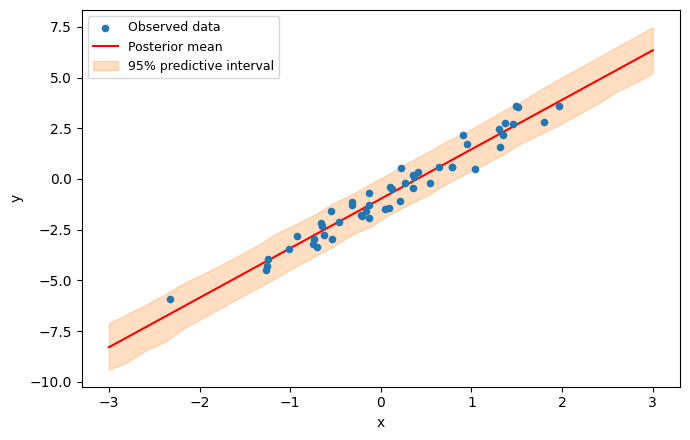

In [57]:
# Plot: observed data, posterior mean line, and 95% predictive interval
mu_samples: np.ndarray = ppc.predictions["mu"].values  # (chains, draws, N_new)
y_samples: np.ndarray = ppc.predictions["y_obs"].values

# Flatten chains and draws -> (n_samples, N_new)
mu_flat: np.ndarray = mu_samples.reshape(-1, len(x_new))
y_flat: np.ndarray = y_samples.reshape(-1, len(x_new))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x, y_reg, s=20, zorder=3, label="Observed data")
ax.plot(x_new, mu_flat.mean(axis=0), "r-", lw=1.5, label="Posterior mean")
ax.fill_between(
    x_new,
    np.percentile(y_flat, 2.5, axis=0),
    np.percentile(y_flat, 97.5, axis=0),
    alpha=0.25,
    color="C1",
    label="95% predictive interval",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Summary cheat sheet

| Task | NumPyro | PyMC 5 |
|---|---|---|
| Define model | `def model(...):` | `with pm.Model() as m:` |
| Sample a parameter | `numpyro.sample("x", dist.Normal(0,1))` | `pm.Normal("x", mu=0, sigma=1)` |
| Observe data | `numpyro.sample("y", dist.Normal(mu,s), obs=y)` | `pm.Normal("y", mu=mu, sigma=s, observed=y)` |
| Derived quantity in trace | `numpyro.deterministic("d", expr)` | `pm.Deterministic("d", expr)` |
| Vectorised parameters | `with numpyro.plate("i", N):` | `shape=N` or `dims="i"` |
| Register swappable data | pass as function arg | `pm.Data("x", vals)` + `pm.set_data(...)` |
| Run NUTS | `MCMC(NUTS(model)).run(key)` | `pm.sample(...)` |
| Get posterior draws | `mcmc.get_samples()["x"]` (JAX array) | `idata.posterior["x"]` (xarray) |
| To plain numpy | already numpy-like | `.values` on the DataArray |
| Posterior predictive | `Predictive(model, samples)(key)` | `pm.sample_posterior_predictive(idata)` |
| Summary table | `mcmc.print_summary()` | `az.summary(idata)` |
| Trace plot | manual or ArviZ | `az.plot_trace(idata)` |

---

## Exercises

### Exercise 1: Poisson-Gamma model

Translate the following NumPyro model into PyMC. Sample from it and print an `az.summary`.

```python
def poisson_gamma_model(y: np.ndarray | None = None) -> None:
    rate = numpyro.sample("rate", dist.Gamma(2.0, 0.5))
    numpyro.sample("y", dist.Poisson(rate), obs=y)
```

Use this synthetic data:

```python
rng = np.random.default_rng(1)
y_counts = rng.poisson(lam=5.0, size=30)
```

---

**Stop and try.** Write your PyMC model in the cell below before checking the solution.

<details><summary>Hint</summary>

PyMC's Gamma is parameterised as `pm.Gamma("rate", alpha=..., beta=...)` where `alpha` is the shape and `beta` is the rate (inverse scale). This matches NumPyro's `dist.Gamma(concentration, rate)`.

</details>

<details><summary>Solution</summary>

```python
rng = np.random.default_rng(1)
y_counts = rng.poisson(lam=5.0, size=30)

with pm.Model() as poisson_gamma:
    rate = pm.Gamma("rate", alpha=2.0, beta=0.5)
    y = pm.Poisson("y", mu=rate, observed=y_counts)

with poisson_gamma:
    idata_pg = pm.sample(draws=1000, tune=500, chains=2, random_seed=42)

az.summary(idata_pg, var_names=["rate"])
```

</details>

In [64]:
# Exercise 1: your PyMC model here
rng = np.random.default_rng(1)
y_counts = rng.poisson(lam=5.0, size=30)

with pm.Model() as model:
    rate = pm.Gamma("rate", alpha=2.0, beta=0.5)
    pm.Poisson("y", mu=rate, observed=y_counts)


with model:
    idata = pm.sample(draws=1000)

az.summary(idata)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rate]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rate,5.444,0.421,4.674,6.265,0.01,0.007,1751.0,2597.0,1.0


### Exercise 2: Hierarchical normal model

Translate this NumPyro hierarchical model into PyMC. There are `J=5` groups, each with its own mean drawn from a shared population prior.

```python
def hierarchical_model(group_idx: np.ndarray,
                       y: np.ndarray | None = None) -> None:
    J = 5
    # Population-level
    mu_pop = numpyro.sample("mu_pop", dist.Normal(0.0, 10.0))
    sigma_pop = numpyro.sample("sigma_pop", dist.HalfNormal(5.0))
    # Group-level
    with numpyro.plate("groups", J):
        mu_group = numpyro.sample("mu_group", dist.Normal(mu_pop, sigma_pop))
    # Observation-level
    sigma_obs = numpyro.sample("sigma_obs", dist.HalfNormal(1.0))
    numpyro.sample("y", dist.Normal(mu_group[group_idx], sigma_obs), obs=y)
```

Use this synthetic data:

```python
rng = np.random.default_rng(2)
J: int = 5
true_mu_group = rng.normal(loc=3.0, scale=2.0, size=J)
group_idx = np.repeat(np.arange(J), 20)
y_hier = rng.normal(loc=true_mu_group[group_idx], scale=0.5)
```

---

**Stop and try.** Write your PyMC model in the cell below before checking the solution.

<details><summary>Hint</summary>

The PyMC equivalent of `numpyro.plate("groups", J)` + `numpyro.sample(...)` is simply passing `shape=J` to the distribution:

```python
mu_group = pm.Normal("mu_group", mu=mu_pop, sigma=sigma_pop, shape=J)
```

Then index into it with `mu_group[group_idx]` as before.

</details>

<details><summary>Solution</summary>

```python
rng = np.random.default_rng(2)
J: int = 5
true_mu_group = rng.normal(loc=3.0, scale=2.0, size=J)
group_idx = np.repeat(np.arange(J), 20)
y_hier = rng.normal(loc=true_mu_group[group_idx], scale=0.5)

with pm.Model() as hierarchical:
    mu_pop = pm.Normal("mu_pop", mu=0.0, sigma=10.0)
    sigma_pop = pm.HalfNormal("sigma_pop", sigma=5.0)
    mu_group = pm.Normal("mu_group", mu=mu_pop, sigma=sigma_pop, shape=J)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1.0)
    y_lik = pm.Normal("y", mu=mu_group[group_idx], sigma=sigma_obs,
                      observed=y_hier)

with hierarchical:
    idata_hier = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

az.summary(idata_hier, var_names=["mu_pop", "sigma_pop", "mu_group", "sigma_obs"])
```

</details>

In [ ]:
# Exercise 2: your PyMC model here
rng = np.random.default_rng(2)
J = 5
true_mu_group = rng.normal(loc=3.0, scale=2.0, size=J)
group_idx = np.repeat(np.arange(J), 20)
y_hier = rng.normal(loc=true_mu_group[group_idx], scale=0.5)

with pm.Model() as hier_model:
    mu_pop = pm.Normal("mu_pop", mu=0.0, sigma=10.0)
    sigma_pop = pm.HalfNormal("sigma_pop", sigma=5.0)
    mu_group = pm.Normal("mu_group", mu=mu_pop, sigma=sigma_pop, shape=J)
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=1.0)
    pm.Normal("y", mu=mu_group[group_idx], sigma=sigma_obs, observed=y_hier)

with hier_model:
    idata = pm.sample(draws=1000)

az.summary(idata, var_names=["mu_pop", "sigma_pop", "mu_group", "sigma_obs"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_pop, sigma_pop, mu_group, sigma_obs]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_pop,2.395,1.785,-1.025,5.794,0.031,0.048,3588.0,2407.0,1.0
sigma_pop,3.778,1.442,1.676,6.438,0.026,0.031,3349.0,2855.0,1.0
mu_group[0],3.405,0.106,3.211,3.606,0.001,0.002,5365.0,2902.0,1.0
mu_group[1],1.955,0.106,1.754,2.152,0.002,0.002,5018.0,3227.0,1.0
mu_group[2],2.320,0.105,2.130,2.518,0.001,0.002,5502.0,2664.0,1.0
mu_group[3],-1.956,0.105,-2.154,-1.765,0.001,0.002,5410.0,2487.0,1.0
mu_group[4],6.517,0.105,6.329,6.722,0.001,0.002,5814.0,2902.0,1.0
sigma_obs,0.471,0.035,0.409,0.536,0.001,0.001,4919.0,2880.0,1.0


### Exercise 3: Robust regression with posterior predictive

This exercise combines several patterns: `pm.Data`, `pm.Deterministic`, a non-normal likelihood, and posterior predictive checking.

Translate this NumPyro robust regression (Student-t likelihood) to PyMC. Then generate posterior predictive samples at new x values and plot the predictive interval.

```python
def robust_reg_model(x: np.ndarray, y: np.ndarray | None = None) -> None:
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0))
    beta = numpyro.sample("beta", dist.Normal(0.0, 10.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(2.0))
    nu = numpyro.sample("nu", dist.Gamma(2.0, 0.1))  # degrees of freedom
    mu = numpyro.deterministic("mu", alpha + beta * x)
    numpyro.sample("y_obs", dist.StudentT(nu, mu, sigma), obs=y)
```

Use this synthetic data (note the outliers):

```python
rng = np.random.default_rng(3)
N = 40
x_rob = rng.normal(size=N)
y_rob = 1.5 * x_rob + 0.5 + rng.normal(scale=0.3, size=N)
# Add a few outliers
y_rob[0] = 10.0
y_rob[1] = -8.0
```

After fitting, generate predictions on `x_pred = np.linspace(-3, 3, 30)` and plot:
- The observed data (scatter)
- The posterior mean line
- The 95% predictive interval

---

**Stop and try.** This exercises all the key patterns from the notebook.

<details><summary>Hint</summary>

1. Use `pm.Data("x_data", x_rob)` so you can swap x later.
2. PyMC's Student-t is `pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=y_rob)`.
3. After sampling, use `pm.set_data({"x_data": x_pred})` then `pm.sample_posterior_predictive(...)`.
4. Remember to request `var_names=["mu", "y_obs"]` in the posterior predictive call.

</details>

<details><summary>Solution</summary>

```python
rng = np.random.default_rng(3)
N = 40
x_rob = rng.normal(size=N)
y_rob = 1.5 * x_rob + 0.5 + rng.normal(scale=0.3, size=N)
y_rob[0] = 10.0
y_rob[1] = -8.0

with pm.Model() as robust_reg:
    x_data = pm.Data("x_data", x_rob)
    alpha = pm.Normal("alpha", mu=0.0, sigma=10.0)
    beta = pm.Normal("beta", mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=2.0)
    nu = pm.Gamma("nu", alpha=2.0, beta=0.1)
    mu = pm.Deterministic("mu", alpha + beta * x_data)
    y_lik = pm.StudentT("y_obs", nu=nu, mu=mu, sigma=sigma, observed=y_rob)

with robust_reg:
    idata_rob = pm.sample(draws=1000, tune=1000, chains=2, random_seed=42)

# Posterior predictive at new x values
x_pred = np.linspace(-3, 3, 30)
with robust_reg:
    pm.set_data({"x_data": x_pred})
    ppc_rob = pm.sample_posterior_predictive(idata_rob,
                                             var_names=["mu", "y_obs"],
                                             random_seed=42)

# Plot
mu_pp = ppc_rob.posterior_predictive["mu"].values.reshape(-1, len(x_pred))
y_pp = ppc_rob.posterior_predictive["y_obs"].values.reshape(-1, len(x_pred))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_rob, y_rob, s=20, zorder=3, label="Observed (inc. outliers)")
ax.plot(x_pred, mu_pp.mean(axis=0), "r-", lw=1.5, label="Posterior mean")
ax.fill_between(x_pred,
                np.percentile(y_pp, 2.5, axis=0),
                np.percentile(y_pp, 97.5, axis=0),
                alpha=0.25, color="C1", label="95% predictive interval")
ax.legend(fontsize=9)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()
```

</details>

In [82]:
# Exercise 3: your PyMC model here
rng = np.random.default_rng(3)
N = 40
x_rob = rng.normal(size=N)
y_rob = 1.5 * x_rob + 0.5 + rng.normal(scale=0.3, size=N)

y_rob[0] = 10.0
y_rob[1] = -8.0

with pm.Model() as model:
    alpha = pm.Normal("alpha", mu=0.0, sigma=10.0)
    beta = pm.Normal("beta", mu=0.0, sigma=10.0)
    sigma = pm.HalfNormal("sigma", sigma=2.0)
    nu = pm.Gamma("nu", alpha=2.0, beta=0.1)
    mu = pm.Deterministic("mu", alpha + beta * x_rob)
    pm.StudentT("y", nu=nu, mu=mu, sigma=sigma, observed=y_rob)

with model:
    idata = pm.sample(draws=1000)

az.summary(idata)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma, nu]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 26 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.463,0.059,0.345,0.572,0.001,0.001,3772.0,3083.0,1.0
beta,1.520,0.068,1.384,1.636,0.001,0.001,3854.0,2936.0,1.0
sigma,0.278,0.055,0.180,0.380,0.001,0.001,3170.0,2788.0,1.0
nu,1.989,0.624,0.970,3.168,0.011,0.011,3397.0,3187.0,1.0
mu[0],3.565,0.144,3.306,3.840,0.002,0.002,4381.0,3008.0,1.0
mu[1],-3.420,0.189,-3.789,-3.073,0.003,0.003,3571.0,2514.0,1.0
mu[2],1.099,0.063,0.984,1.220,0.001,0.001,4216.0,2932.0,1.0
mu[3],-0.399,0.074,-0.535,-0.256,0.001,0.001,3442.0,2522.0,1.0
mu[4],-0.224,0.070,-0.353,-0.093,0.001,0.001,3471.0,2804.0,1.0
mu[5],0.136,0.063,0.022,0.258,0.001,0.001,3602.0,2768.0,1.0


---

## What comes next

The remaining notebooks in this series use PyMC exclusively. You now have the core translation patterns:

- Context-manager model specification
- `pm.sample()` returning `InferenceData`
- Posterior access via xarray (`.posterior["x"].values`)
- `pm.Data` + `pm.set_data` + `pm.sample_posterior_predictive` for predictions
- `pm.Deterministic` for derived quantities

**Notebook 1** introduces latent-threshold ordinal models -- the modelling framework needed for the DCM observation layer.

## Anki

In [ ]:
# Q: What does predictions=True do in pm.sample_posterior_predictive?
ppc = pm.sample_posterior_predictive(idata, predictions=True)
ppc.predictions["y"]       # out-of-sample forecasts
# vs default (predictions=False):
ppc.posterior_predictive["y"]  # in-sample model checking

In [ ]:
# Q: Out-of-sample prediction recipe in PyMC (3 steps)
# 1. Model: wrap BOTH x and y in pm.Data with dims
x_data = pm.Data("x", x, dims="obs_id")
y_data = pm.Data("y", y, dims="obs_id")  # observed also mutable
# 2. Swap: update both + resize coords
pm.set_data({"x": x_new, "y": np.zeros(len(x_new))},
            coords={"obs_id": np.arange(len(x_new))})
# 3. Sample with predictions=True
ppc = pm.sample_posterior_predictive(idata, predictions=True)

In [ ]:
# Q: Why must observed data be wrapped in pm.Data for out-of-sample prediction?
# PyMC compiles RV nodes with fixed shapes from the observed array.
# Without pm.Data + dims, resizing inputs causes a shape broadcast error
# because the likelihood node retains its original size.
pm.Normal("y", mu=mu, sigma=s, observed=y_raw)   # fixed shape -- can't resize
pm.Normal("y", mu=mu, sigma=s, observed=y_data)   # y_data = pm.Data(...) -- resizeable